In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

pd.set_option("display.max_columns", None)

In [2]:
symbol = "^NSEI"
start  = "2010-01-01"
end    = None

df = yf.download(symbol, start=start, end=end)

# flatten multi-level columns (this is for the recent yfinance versions)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0
2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0
2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0
2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0
2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0


In [6]:
def _merge(df_main, ta_obj):
    """Add TA output to df_main, regardless of Series/DataFrame type."""
    if isinstance(ta_obj, pd.DataFrame):
        return pd.concat([df_main, ta_obj], axis=1)
    else:
        return pd.concat([df_main, ta_obj.rename(ta_obj.name)], axis=1)


def add_indicators(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()

    # ── Momentum ──────────────────────────────────────────────
    for length in [5, 10, 15]:
        df[f"rsi_{length}"] = ta.rsi(df["Close"], length=length)
    df["roc_10"] = ta.roc(df["Close"], length=10)
    df["mom_10"] = ta.mom(df["Close"], length=10)

    # ── Oscillators ───────────────────────────────────────────
    df = _merge(df, ta.stochrsi(df["Close"]))            
    df["cci_20"] = ta.cci(df["High"], df["Low"], df["Close"], length=20)
    df["wr_14"]  = ta.willr(df["High"], df["Low"], df["Close"], length=14)
    df = _merge(df, ta.kst(df["Close"]))                 
    df["macd"]   = ta.macd(df["Close"])["MACD_12_26_9"]  

    # ── Trend ────────────────────────────────────────────────
    for length in [5, 10, 20]:
        df[f"sma_{length}"] = ta.sma(df["Close"], length=length)
        df[f"ema_{length}"] = ta.ema(df["Close"], length=length)
    df["vwma_20"] = ta.vwma(df["Close"], df["Volume"], length=20)

    # ── Volatility ───────────────────────────────────────────
    df = _merge(df, ta.bbands(df["Close"], length=20))  
    df["atr_14"] = ta.atr(df["High"], df["Low"], df["Close"], length=14)
    df = _merge(df, ta.kc(df["High"], df["Low"], df["Close"], length=20))

    # ── Volume ───────────────────────────────────────────────
    df["obv"] = ta.obv(df["Close"], df["Volume"])
    df["ad"]  = ta.ad(df["High"], df["Low"], df["Close"], df["Volume"])
    df["efi"] = ta.efi(df["Close"], df["Volume"])
    df["nvi"] = ta.nvi(df["Close"], df["Volume"])
    
    # ← FIXED: use _merge like the other multi-column indicators
    df = _merge(df, ta.pvi(df["Close"], df["Volume"]))

    return df


df_ta = add_indicators(df)
df_ta.tail()

,Close,High,Low,Open,Volume,rsi_5,rsi_10,rsi_15,roc_10,mom_10,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,cci_20,wr_14,KST_10_15_20_30_10_10_10_15,KSTs_9,macd,sma_5,ema_5,sma_10,ema_10,sma_20,ema_20,vwma_20,BBL_20_2.0_2.0,BBM_20_2.0_2.0,BBU_20_2.0_2.0,BBB_20_2.0_2.0,BBP_20_2.0_2.0,atr_14,KCLe_20_2,KCBe_20_2,KCUe_20_2,obv,ad,efi,nvi,PVI,PVIe_255
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-03-11,23866.849609,24299.000000,23834.300781,24231.849609,407400,23.204439,27.039831,30.196832,-6.127128,-1557.800781,9.186800,11.973237,20987.646991,-92.272054,-3256.533849,-1468.755497,-397.724804,24274.569922,24241.904694,24687.675000,24573.646866,25174.982422,24943.184888,25087.574151,23878.342030,25174.982422,26471.622814,10.301023,-0.004432,360.200648,24185.375843,24943.184888,25700.993932,72040600.0,4.107960e+07,-6.820303e+07,1145.395165,100.000000,99.966007
2026-03-12,23639.150391,23833.150391,23556.300781,23674.849609,501000,19.538848,24.591831,28.170679,-7.233786,-1843.349609,9.186800,10.060593,20964.601558,-96.259862,-3876.398320,-1881.487898,-450.723468,24049.219922,24040.986593,24503.340039,24403.738416,25059.247461,24818.991126,24966.206049,23647.245019,25059.247461,26471.249903,11.269312,-0.002866,356.654090,24074.202214,24818.991126,25563.780038,71539600.0,4.087845e+07,-7.475650e+07,1145.395165,99.045960,99.958820
2026-03-13,23151.099609,23492.400391,23112.000000,23462.500000,519800,13.728430,20.230039,24.409407,-9.199092,-2345.451172,1.974201,6.782601,20813.412564,-98.529785,-4607.970558,-2368.030644,-526.043014,23789.350000,23744.357598,24268.794922,24175.985905,24926.442480,24660.144315,24812.714567,23323.867586,24926.442480,26529.017375,12.858433,-0.053903,368.832397,23885.878082,24660.144315,25434.410548,71019800.0,4.046551e+07,-1.003183e+08,1145.395165,97.935413,99.943012
2026-03-16,23408.800781,23502.000000,22955.250000,23116.099609,540300,27.883294,27.748514,29.718190,-7.029168,-1769.849609,8.187128,6.449376,21037.235494,-83.185317,-5165.147306,-2886.835303,-558.501903,23665.500000,23632.505326,24091.809961,24036.497701,24823.327539,24540.968740,24688.809059,23106.960445,24823.327539,26539.694633,13.828663,0.087930,381.540797,23736.299291,24540.968740,25345.638189,71560100.0,4.082161e+07,-6.609623e+07,1145.395165,101.113127,99.952153
2026-03-17,23581.150391,23656.800781,23346.599609,23493.199219,0,36.581996,32.477727,33.085659,-5.165947,-1284.548828,21.560576,10.573968,21363.610386,-76.795726,-5635.550340,-3405.663266,-563.819277,23529.410156,23615.387014,23963.355078,23953.707281,24718.247559,24449.557469,24655.604656,22966.456772,24718.247559,26470.038346,14.174069,0.175447,376.445109,23662.437268,24449.557469,25236.677670,71560100.0,4.082161e+07,-5.665391e+07,1146.131425,100.000000,99.952527


In [7]:
def generate_label(
        data: pd.DataFrame,
        lookahead: int = 5,
        thresh: float = 0.01,
        col: str = "Close"
) -> pd.Series:
    """
    Label each row from the mean of the *next* `lookahead` closes:
      2 : future_mean ≥ current * (1 + thresh)
      1 : future_mean ≤ current * (1 - thresh)
      0 : otherwise
    """
    future_mean = (
        data[col]
        .shift(-lookahead)
        .rolling(window=lookahead, min_periods=lookahead)
        .mean()
    )
    #data["means"] = future_mean
    pct_change = (future_mean - data[col]) / data[col]

    labels = np.select(
        [pct_change >= thresh, pct_change <= -thresh],
        [2, 1],
        default=0
    )

    return pd.Series(labels, index=data.index)



# Now compute the labels for different lookaheads and thresholds
# --------------------------------------------------------------
lookaheads = [2,4,6,8,10]
thresholds = [0.01, 0.02]

for la in lookaheads:
    for th in thresholds:
        df_ta[f"label_la{la}_th{th:.3f}"] = generate_label(df_ta, lookahead=la, thresh=th)
#---------------------------------------------------------------

df_ta.dropna(inplace=True)
df_ta.head()

,Close,High,Low,Open,Volume,rsi_5,rsi_10,rsi_15,roc_10,mom_10,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,cci_20,wr_14,KST_10_15_20_30_10_10_10_15,KSTs_9,macd,sma_5,ema_5,sma_10,ema_10,sma_20,ema_20,vwma_20,BBL_20_2.0_2.0,BBM_20_2.0_2.0,BBU_20_2.0_2.0,BBB_20_2.0_2.0,BBP_20_2.0_2.0,atr_14,KCLe_20_2,KCBe_20_2,KCUe_20_2,obv,ad,efi,nvi,PVI,PVIe_255,label_la2_th0.010,label_la2_th0.020,label_la4_th0.010,label_la4_th0.020,label_la6_th0.010,label_la6_th0.020,label_la8_th0.010,label_la8_th0.020,label_la10_th0.010,label_la10_th0.020
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-01-21,6082.299805,6094.350098,6065.100098,6085.750000,130900,71.660129,67.211705,65.544297,1.568030,93.899902,65.803979,57.129135,-1300.006507,-7.837589,3184.093990,3023.657871,55.186115,6048.870020,6049.771814,6016.154980,6024.030449,5973.07251,5982.861884,6082.299805,5832.670050,5973.07251,6113.474969,4.701180,0.888979,56.564763,5871.321394,5982.861884,6094.402373,130900.0,23044.728232,3.347282e+05,1000.000000,100.295164,100.002306,0,0,0,0,0,0,0,0,0,0
2013-01-22,6048.500000,6101.299805,6040.500000,6080.149902,129000,56.299287,59.914854,60.755191,0.779776,46.799805,61.373948,58.610426,-1961.972181,-32.856192,3161.605689,3054.425219,53.751292,6047.250000,6049.347876,6020.834961,6028.479458,5983.11250,5989.113133,6065.523449,5852.051163,5983.11250,6114.173837,4.381042,0.749454,56.867266,5876.614632,5989.113133,6101.611634,1900.0,-72007.794295,-3.359723e+05,999.444292,100.000000,100.002288,0,0,0,0,0,0,0,0,0,0
2013-01-23,6054.299805,6069.799805,6021.149902,6052.850098,137000,58.220222,60.727746,61.275390,1.386583,82.799805,52.253518,59.810482,-3035.283242,-29.247098,3072.300041,3079.845137,52.477256,6057.739941,6050.998519,6029.114941,6033.174067,5993.03999,5995.321387,6061.649326,5872.981736,5993.03999,6113.098245,4.006589,0.755125,56.280312,5884.270381,5995.321387,6106.372394,138900.0,-22304.989056,-1.744658e+05,999.444292,100.095888,100.003019,0,0,0,0,0,0,0,0,0,0
2013-01-24,6019.350098,6065.299805,6007.850098,6046.200195,185200,43.738298,53.467856,56.444759,0.849442,50.700195,25.283046,46.303504,-4098.108638,-50.995555,2916.094166,3089.273617,48.093037,6053.769922,6040.449045,6034.184961,6030.660618,5998.72749,5997.609836,6048.191472,5885.529052,5998.72749,6111.925928,3.774082,0.591091,56.363840,5886.192315,5997.609836,6109.027357,-46300.0,-133360.137496,-1.074211e+06,999.444292,99.422729,99.998486,0,0,0,0,0,0,0,0,0,0
2013-01-25,6074.649902,6080.549805,6014.450195,6024.500000,147600,62.290437,61.549234,61.579557,2.072658,123.350098,30.318543,35.951702,-5178.103461,-16.583666,2879.140791,3084.449332,48.521419,6055.819922,6051.849331,6046.519971,6038.658669,6008.95498,6004.946985,6053.543348,5908.437231,6008.95498,6109.472730,3.345598,0.826783,57.059252,5891.550254,6004.946985,6118.343716,101300.0,-12109.025006,2.452832e+05,1000.362993,100.000000,99.998498,0,0,0,0,0,0,0,0,1,0


In [8]:
# Use chronological split: 60% train, 20% test, 20% validation
# ---------------------------------------------------------------
split_idx = int(len(df_ta) * 0.6)
split_idx_val = int(len(df_ta) * 0.8)
train_df, test_df = df_ta.iloc[:split_idx], df_ta.iloc[split_idx:split_idx_val]
val_df = df_ta.iloc[split_idx_val:]

feature_cols = [c for c in df_ta.columns if c not in ["Open","High","Low","Close","Adj Close","Volume"] and not c.startswith("label_")]
print("Total features:", len(feature_cols))

Total features: 34


In [ ]:
results = []

for label_col in [c for c in df_ta.columns if c.startswith("label_")]:
    X_train, y_train = train_df[feature_cols], train_df[label_col]
    X_test,  y_test  = test_df[feature_cols],  test_df[label_col]
    
    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=3,
        n_jobs=-1,
        eval_metric='mlogloss',
        seed=42
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    acc  = accuracy_score(y_test, preds)
    f1   = f1_score(y_test, preds, average='macro')
    
    results.append({
        "label": label_col,
        "accuracy": acc,
        "f1_macro": f1
    })

pd.DataFrame(results).sort_values("accuracy", ascending=False).head(10)

,label,accuracy,f1_macro
1,label_la2_th0.020,0.913447,0.350249
3,label_la4_th0.020,0.755796,0.332836
5,label_la6_th0.020,0.718702,0.343847
7,label_la8_th0.020,0.610510,0.341988
9,label_la10_th0.020,0.514683,0.329199
0,label_la2_th0.010,0.506955,0.360214
2,label_la4_th0.010,0.366306,0.329134
8,label_la10_th0.010,0.309119,0.309260
6,label_la8_th0.010,0.298300,0.297119
4,label_la6_th0.010,0.295209,0.295210


In [11]:
#best_label = max(results, key=lambda x: x["f1_macro"])["label"]
# print("Best label:", best_label)

best_label = "label_la2_th0.020"  # Replace with custom label from results

X_train, y_train = train_df[feature_cols], train_df[best_label]
X_test,  y_test  = test_df[feature_cols],  test_df[best_label]

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth":   [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample":  [0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}
tscv = TimeSeriesSplit(n_splits=5)

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_jobs=-1,
    eval_metric='mlogloss',
    seed=42
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

best_model = grid.best_estimator_
test_preds = best_model.predict(X_test)
print(classification_report(y_test, test_preds))

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best params: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV accuracy: 0.9405572755417957
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       604
           1       0.07      0.05      0.05        22
           2       0.00      0.00      0.00        21

    accuracy                           0.92       647
   macro avg       0.34      0.34      0.34       647
weighted avg       0.88      0.92      0.90       647



c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [12]:
X_val,  y_val  = val_df[feature_cols],  val_df[best_label]
val_preds = best_model.predict(X_val)
print(classification_report(y_val, val_preds))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       629
           1       0.06      0.10      0.08        10
           2       0.00      0.00      0.00         8

    accuracy                           0.95       647
   macro avg       0.35      0.36      0.35       647
weighted avg       0.95      0.95      0.95       647



c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [13]:
THRESH_1 = 0.55   # class 1  (bearish sell)
THRESH_2 = 0.55  # class 2  (bullish buy)

import numpy as np

def custom_select(proba: np.ndarray,
                  thr1: float = 0.65,
                  thr2: float = 0.65,
                  neutral_label: int = 0) -> np.ndarray:
    """
    Parameters
    ----------
    proba : ndarray, shape (n_samples, 3)
        Class-probability matrix from XGBClassifier.predict_proba().
        Column indices: 0 → neutral / 'no trade', 1 → class 1, 2 → class 2.
    thr1, thr2 : float
        Minimum probability required to accept class 1 or class 2 respectively.
    neutral_label : int
        Label to assign when the confidence criteria are not met.

    Returns
    -------
    pred : ndarray, shape (n_samples,)
        Final class predictions after thresholding.
    """
    # start with everyone assigned to 'neutral'
    pred = np.full(len(proba), neutral_label, dtype=int)

    # --- choose class 1 if it is:
    #     • the highest-probability class AND
    #     • above its own threshold
    mask1 = (proba[:, 1] >= thr1) & (proba[:, 1] > proba[:, 2])
    pred[mask1] = 1

    # --- choose class 2 under analogous conditions
    mask2 = (proba[:, 2] >= thr2) & (proba[:, 2] > proba[:, 1])
    pred[mask2] = 2

    # rest of rows remain neutral_label
    return pred


#from sklearn.metrics import make_scorer, f1_score
# def selective_f1(y_true, y_proba, thr1, thr2):
#     pred = custom_select(y_proba, thr1, thr2)
#     return f1_score(y_true, pred, average='macro')

In [14]:
import numpy as np

def selective_predict_proba(proba: np.ndarray,
                            thr1: float = 0.65,
                            thr2: float = 0.65) -> np.ndarray:
    """
    Convert a [n_samples, 3] probability matrix into
    class labels 0/1/2 with optional abstention (e.g. -1).
    """
    pred = np.zeros(len(proba), dtype=int)  # default = class 0

    # take class 1 only if it's clearly on top *and* above its threshold
    mask1 = (proba[:, 1] >= thr1) & (proba[:, 1] > proba[:, 2])
    pred[mask1] = 1

    # take class 2 under the analogous rule
    mask2 = (proba[:, 2] >= thr2) & (proba[:, 2] > proba[:, 1])
    pred[mask2] = 2

    # optional: flag low-confidence points instead of forcing them to 0
    # pred[~(mask1 | mask2)] = -1
    return pred

In [15]:
X_train, y_train = train_df[feature_cols], train_df[best_label]
X_test,  y_test  = test_df[feature_cols],  test_df[best_label]

y_proba = best_model.predict_proba(X_test)
sel_preds = selective_predict_proba(y_proba, THRESH_1, THRESH_2)

test_df["sel_preds"] = sel_preds
print(classification_report(y_test, sel_preds))

y_proba = best_model.predict_proba(X_val)
sel_preds = selective_predict_proba(y_proba, THRESH_1, THRESH_2)
val_df["sel_preds"] = sel_preds

              precision    recall  f1-score   support

           0       0.93      1.00      0.96       604
           1       0.00      0.00      0.00        22
           2       0.00      0.00      0.00        21

    accuracy                           0.93       647
   macro avg       0.31      0.33      0.32       647
weighted avg       0.87      0.93      0.90       647



c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

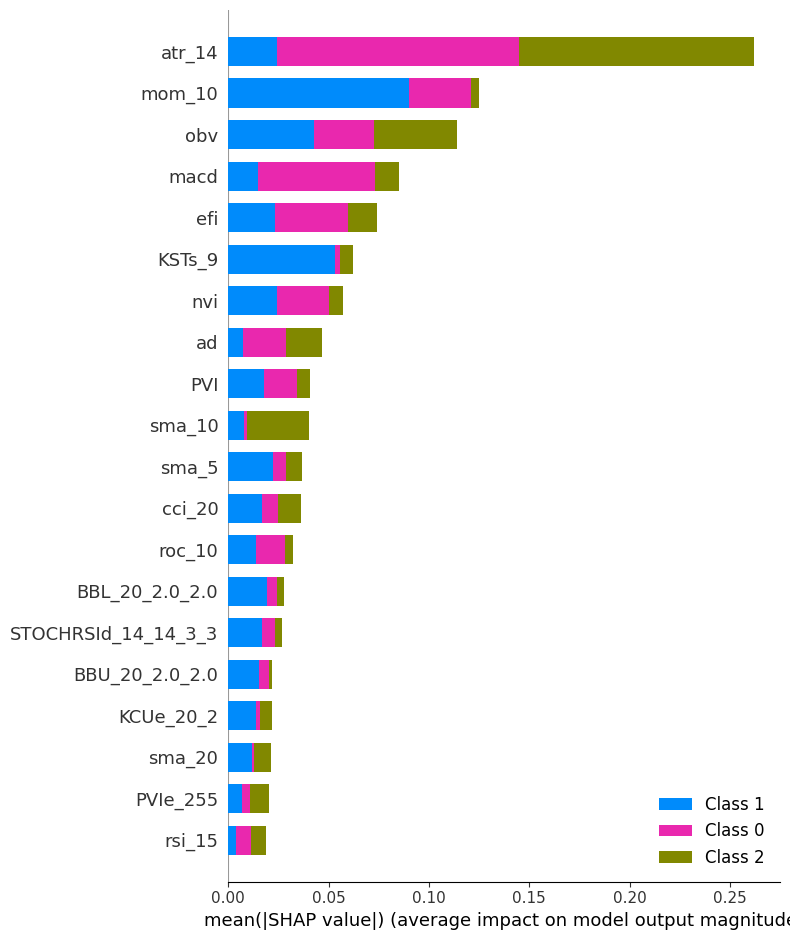

In [16]:
import shap
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val)
shap.summary_plot(shap_values, X_val, plot_type="bar")

In [17]:
val_df["predictions"] = best_model.predict(X_val)

In [18]:
import plotly.graph_objs as go

def plot_signals(test_df, pred_column='predictions', start=0, length=100):
    """
    Plot OHLC candles from test_df with:
    • purple dots for model signals
    • EMA line
    """
    # Subset
    df_slice = test_df.iloc[start:start+length].copy()
    df_slice.reset_index(inplace=True)  # Reset for plotting

    # Candle plot
    fig = go.Figure(data=[go.Candlestick(
        x=df_slice['index'] if 'index' in df_slice else df_slice.index,
        open=df_slice['Open'],
        high=df_slice['High'],
        low=df_slice['Low'],
        close=df_slice['Close'],
        name='Candles'
    )])

    
    if 'ema' in df_slice.columns:                     # adjust column name if needed
        fig.add_trace(go.Scatter(
            x=df_slice['index'] if 'index' in df_slice else df_slice.index,
            y=df_slice['ema'],
            mode='lines',
            line=dict(width=1.5, dash='dot', color='orange'),
            name='EMA'
        ))
    

    # Bullish signals
    bull_idx = df_slice[df_slice[pred_column] == 2].index
    fig.add_trace(go.Scatter(
        x=df_slice.loc[bull_idx, 'index'] if 'index' in df_slice else bull_idx,
        y=df_slice.loc[bull_idx, 'Low'] - (df_slice['High']-df_slice['Low']).mean()*0.1,
        mode='markers',
        marker=dict(size=7, color='purple', symbol='circle'),
        name='Bullish signal (2)'
    ))

    # Bearish signals
    bear_idx = df_slice[df_slice[pred_column] == 1].index
    fig.add_trace(go.Scatter(
        x=df_slice.loc[bear_idx, 'index'] if 'index' in df_slice else bear_idx,
        y=df_slice.loc[bear_idx, 'High'] + (df_slice['High']-df_slice['Low']).mean()*0.1,
        mode='markers',
        marker=dict(size=7, color='purple', symbol='circle'),
        name='Bearish signal (1)'
    ))


    # Bullish labels
    bull_idx = df_slice[df_slice[best_label] == 2].index
    fig.add_trace(go.Scatter(
        x=df_slice.loc[bull_idx, 'index'] if 'index' in df_slice else bull_idx,
        y=df_slice.loc[bull_idx, 'Low'] - (df_slice['High']-df_slice['Low']).mean()*0.5,
        mode='markers',
        marker=dict(size=7, color='red', symbol='triangle-up'),
        name='Bullish Label (2)'
    ))

    # Bearish labels
    bear_idx = df_slice[df_slice[best_label] == 1].index
    fig.add_trace(go.Scatter(
        x=df_slice.loc[bear_idx, 'index'] if 'index' in df_slice else bear_idx,
        y=df_slice.loc[bear_idx, 'High'] + (df_slice['High']-df_slice['Low']).mean()*0.5,
        mode='markers',
        marker=dict(size=7, color='red', symbol='triangle-down'),
        name='Bearish Label (1)'
    ))

    fig.update_layout(
        title=f"Signals (purple) & EMA from index {start} to {start+length}",
        xaxis_title="Index",
        yaxis_title="Price",
        showlegend=True,
        height=600,
        width=1000
    )
    fig.show()


plot_signals(val_df, pred_column="sel_preds", start=0, length=160)

In [19]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

y_pred   = best_model.predict(X_test)
y_proba  = best_model.predict_proba(X_test)

print("----- Classification report -----")
print(classification_report(y_test, y_pred, digits=4))

summary = {
    "Accuracy"          : accuracy_score(y_test, y_pred),
    "Balanced accuracy" : balanced_accuracy_score(y_test, y_pred),
    "Macro-F1"          : f1_score(y_test, y_pred, average="macro"),
    "Macro-Precision"   : precision_score(y_test, y_pred, average="macro"),
    "Macro-Recall"      : recall_score(y_test, y_pred, average="macro"),
    "MCC"               : matthews_corrcoef(y_test, y_pred)
}
pd.DataFrame(summary, index=["Score"]).T.style.format("{:.4f}")

----- Classification report -----
              precision    recall  f1-score   support

           0     0.9415    0.9851    0.9628       604
           1     0.0667    0.0455    0.0541        22
           2     0.0000    0.0000    0.0000        21

    accuracy                         0.9212       647
   macro avg     0.3360    0.3435    0.3389       647
weighted avg     0.8812    0.9212    0.9006       647



c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined

,Score
Accuracy,0.9212
Balanced accuracy,0.3435
Macro-F1,0.3389
Macro-Precision,0.3360
Macro-Recall,0.3435
MCC,0.1123


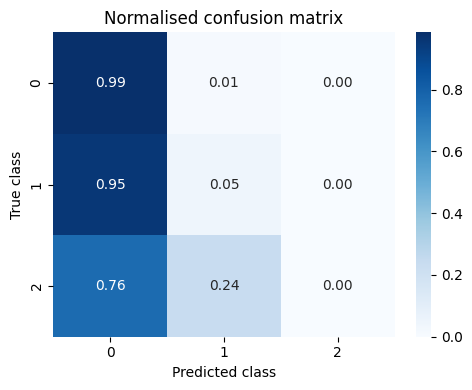

In [20]:
# Confusion-matrix heat-map (normalised row-wise)
cm  = confusion_matrix(y_test, y_pred, labels=[0,1,2])
cmn = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(5,4))
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["0","1","2"], yticklabels=["0","1","2"])
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Normalised confusion matrix")
plt.tight_layout()
plt.show()

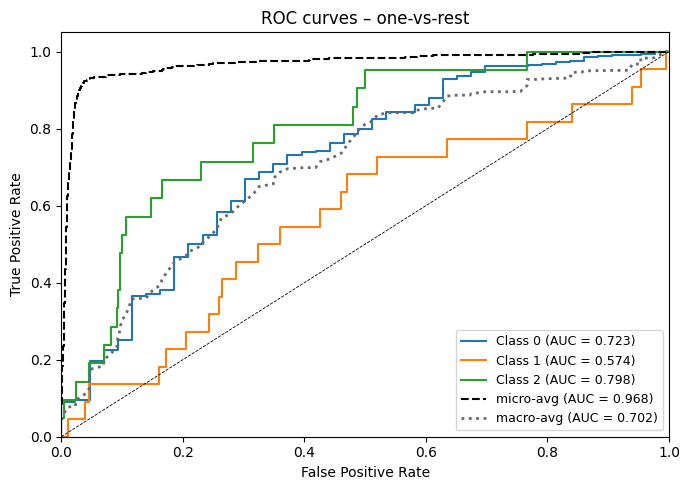

In [21]:
# ROC curves (one-vs-rest) + macro/micro averages
n_classes = 3
fpr = dict(); tpr = dict(); roc_auc = dict()

# one-vs-rest curves
for c in range(n_classes):
    fpr[c], tpr[c], _ = roc_curve((y_test == c).astype(int), y_proba[:, c])
    roc_auc[c] = auc(fpr[c], tpr[c])

# micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(
    pd.get_dummies(y_test).values.ravel(), y_proba.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# macro-average (average the FPR points first, then AU-C)
all_fpr = np.unique(np.concatenate([fpr[c] for c in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for c in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
mean_tpr /= n_classes
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# ---------- Plot ----------
plt.figure(figsize=(7,5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # default matplotlib palette

for c, col in zip(range(n_classes), colors):
    plt.plot(fpr[c], tpr[c], color=col,
             label=f"Class {c} (AUC = {roc_auc[c]:.3f})", lw=1.5)

# macro & micro
plt.plot(fpr["micro"], tpr["micro"], linestyle="--", color="black",
         label=f"micro-avg (AUC = {roc_auc['micro']:.3f})", lw=1.5)
plt.plot(fpr["macro"], tpr["macro"], linestyle=":", color="dimgray",
         label=f"macro-avg (AUC = {roc_auc['macro']:.3f})", lw=2)

plt.plot([0,1], [0,1], "k--", lw=0.6)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves – one-vs-rest")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [22]:
print("\nArea-under-curve (AUC) scores:")
auc_tbl = pd.DataFrame(
    {f"Class {c}": roc_auc[c] for c in range(n_classes)} |
    {"micro-avg": roc_auc["micro"], "macro-avg": roc_auc["macro"]},
    index=["AUC"]
).T
auc_tbl.style.format("{:.4f}")


Area-under-curve (AUC) scores:


,AUC
Class 0,0.7227
Class 1,0.5737
Class 2,0.7975
micro-avg,0.9682
macro-avg,0.7019


In [ ]:
                                                   # ==================================================
# Walk-Forward (Rolling window) Validation Approach
# ==================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
import pandas as pd

n_splits = 5  # change this for more/less rolling windows
tscv = TimeSeriesSplit(n_splits=n_splits)

fold_metrics = []

print(f"\nWalk-forward validation ({n_splits} splits) on label: {best_label}\n")
for fold, (train_idx, test_idx) in enumerate(tscv.split(df_ta)):
    train = df_ta.iloc[train_idx]
    test = df_ta.iloc[test_idx]
    X_train, y_train = train[feature_cols], train[best_label]
    X_test, y_test = test[feature_cols], test[best_label]

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=3,
        n_jobs=-1,
        eval_metric='mlogloss',
        seed=42,
        use_label_encoder=False
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    metrics = {
        "fold": fold+1,
        "start": test.index[0],
        "end": test.index[-1],
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "precision_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
    }
    fold_metrics.append(metrics)
    print(f"Fold {fold+1}: {test.index[0]} to {test.index[-1]}")
    print(f"  Accuracy: {metrics['accuracy']:.4f}, F1-macro: {metrics['f1_macro']:.4f}\n")

# summary DataFrame
results_df = pd.DataFrame(fold_metrics)
display(results_df)

print("\nMean (±std) metrics across folds:")
for m in ["accuracy", "f1_macro", "precision_macro", "recall_macro"]:
    print(f"{m:15}: {results_df[m].mean():.4f} ± {results_df[m].std():.4f}")


Walk-forward validation (5 splits) on label: label_la2_th0.020



c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning:

[18:05:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




Fold 1: 2015-04-20 00:00:00 to 2017-06-23 00:00:00
  Accuracy: 0.8941, F1-macro: 0.3150



c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning:

[18:05:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning:

[18:05:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




Fold 2: 2017-06-27 00:00:00 to 2019-09-04 00:00:00
  Accuracy: 0.9740, F1-macro: 0.3289



...

c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning:

[18:05:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




Fold 4: 2021-11-10 00:00:00 to 2024-01-10 00:00:00
  Accuracy: 0.9405, F1-macro: 0.3234

Fold 5: 2024-01-11 00:00:00 to 2026-03-17 00:00:00
  Accuracy: 0.9684, F1-macro: 0.3280



c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



,fold,start,end,accuracy,f1_macro,precision_macro,recall_macro
0,1,2015-04-20,2017-06-23,0.894052,0.314997,0.316864,0.313151
1,2,2017-06-27,2019-09-04,0.973978,0.328939,0.324659,0.333333
2,3,2019-09-05,2021-11-09,0.894052,0.314688,0.298572,0.332642
3,4,2021-11-10,2024-01-10,0.940520,0.323426,0.315265,0.332021
4,5,2024-01-11,2026-03-17,0.968401,0.327982,0.322800,0.333333



Mean (±std) metrics across folds:
accuracy       : 0.9342 ± 0.0388
f1_macro       : 0.3220 ± 0.0069
precision_macro: 0.3156 ± 0.0103
recall_macro   : 0.3289 ± 0.0088


END